# Building an ATLAS analysis, step by step

### A 3-pulsar global fit for the GWB, intrinsic red noise, white noise, and a directly-sampled linear timing model

This notebook walks through the construction of a complete ATLAS analysis on a small
3-pulsar array, explaining **what each object is for** and **why the pieces fit together
the way they do**. The model we build searches simultaneously for

| Component | Model | Sampled? |
|---|---|---|
| Linearised timing model $\epsilon$ | design matrix $M$, flat prior | **yes** — directly, as basis coefficients |
| White noise | EFAC, EQUAD, ECORR per backend | **yes** — varied inside the likelihood |
| Intrinsic red noise (IRN) | power law, per pulsar | **yes** — $\log_{10}A$, $\gamma$ |
| GWB | power law + Hellings–Downs ORF | **yes** — $\log_{10}A$, $\gamma$ |

Everything is in **one posterior**, sampled with NUTS. That is the entire thesis of ATLAS:
conventional PTA analysis fits and freezes the timing solution, then fits and freezes the
white noise, then linearises and marginalises the timing model, and only then samples the
spectra — so timing-model and white-noise uncertainty never propagate into the GWB
posterior. A global fit refuses that staging.

---

## The one thing to internalise before you start

Every piece of data in ATLAS is compressed, exactly once per likelihood evaluation, into
**four arrays**, collectively called `helpers`:

$$
\mathtt{TNT} = T^{\mathsf T} N^{-1} T \;[N_\mathrm{psr}, N_\mathrm{col}, N_\mathrm{col}],
\qquad
\mathtt{TNr} = T^{\mathsf T} N^{-1} r \;[N_\mathrm{psr}, N_\mathrm{col}],
$$
$$
\mathtt{rNr} = r^{\mathsf T} N^{-1} r \;\text{(scalar)},
\qquad
\mathtt{logdet\_N} = \log\det N \;\text{(scalar)}.
$$

Nothing downstream of `helpers` ever touches a TOA again. The whole notebook is really
just: *build the two things that make `helpers`* (a noise covariance $N$ and a design
basis $T$), *then hand `helpers` to a sampler.*

```
  par/tim  ──▶  Pulsar  ──▶  PTA_Data  ──┬──▶  WhiteCov    ──▶  N⁻¹  ──┐
                                         │     (nMatrix)              │
                                         │                            ├──▶ helpers ──▶ likelihood ──▶ NUTS
                                         └──▶  SuperSignal ──▶  T  ───┘
                                               (signals/factorized)
```

## 0. Prerequisites

ATLAS needs `jax`, `numpyro`, `enterprise-pulsar` (plus `pint-pulsar` or `libstempo` to
read par/tim), `scikit-learn`, `joblib`, `tqdm`, `tqdm_joblib`, and **JUG**.

> **Note.** `pyproject.toml` under-declares its dependencies: `scikit-learn`, `tqdm` and
> `tqdm_joblib` are hard imports on the main path but are not listed as runtime
> requirements, and JUG is not on PyPI. `ATLAS.model_builder` imports
> `ATLAS.signals.timing.base`, which imports JUG at module level — so **you need JUG
> installed even for an analysis like this one that never uses the nonlinear timing
> model.** Install it from source alongside ATLAS.

Set `JAX_PLATFORMS=cpu` if you want to force CPU; on a GPU this analysis is much faster,
and ATLAS is written throughout to keep the per-pulsar arrays batched for exactly that
reason.

In [1]:
import os, sys, json, glob, pickle, time
from functools import partial

import numpy as np
import matplotlib.pyplot as plt

import jax
jax.config.update("jax_enable_x64", True)   # ATLAS assumes float64 everywhere
import jax.numpy as jnp
import jax.random as jrandom

import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS, init_to_value

sys.path.append("..")   # so `import ATLAS` works when running from notebooks/

from ATLAS.pulsar import load_pulsars
from ATLAS.data import PTA_Data
from ATLAS.model_builder import ModelBuilder
from ATLAS.nMatrix.base import WhiteCov
from ATLAS.psd_functions import powerlaw, hd_orf
from ATLAS.samplers.canetoadracing import model_maker

print("jax", jax.__version__, "| numpyro", numpyro.__version__)
print("devices:", jax.devices())

/home/coronus/miniconda3/envs/atlas/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/coronus/miniconda3/envs/atlas/lib/python3.12/site-packages/enterprise/signals/utils.py:13: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import Requirement, resource_filename
libstempo not installed. PINT or libstempo are required to use par and tim files.


jax 0.10.1 | numpyro 0.21.0
devices: [CudaDevice(id=0)]


---
# 1. Data → `Pulsar` objects

`ATLAS.pulsar.Pulsar` is a thin container that wraps **one of two backends** behind a
single interface:

* `use_enterprise=True` (default) → `enterprise.pulsar.Pulsar`, which uses PINT or
  libstempo to fit and linearise the timing model;
* `use_enterprise=False` → JUG's `TimingSession`.

Either way it extracts the same things: TOAs, residuals, TOA errors, radio frequencies,
backend flags, sky position, fitted timing parameters, and — crucially — the **linearised
timing design matrix** $M$, whose columns are $\partial r_i / \partial p_j$ for each
timing parameter $p_j$.

`load_pulsars` parallelises the loading over 8 joblib workers. Loading is by far the
slowest step here (PINT has to build a full timing model per pulsar), so we cache.

We use three NANOGrav 15 yr pulsars with long baselines and good sky separation, so the
Hellings–Downs curve is at least in principle sampled at three distinct angles.

In [2]:
DATA_DIR = "../datasets/NG15"
PSR_NAMES = ["B1855+09", "J1455-3330", "J2317+1439"]
CACHE = "psrs_3psr_demo.pkl"

parfiles = [f"{DATA_DIR}/par/{p}_PINT_DMX.par" for p in PSR_NAMES]
timfiles = [f"{DATA_DIR}/tim/{p}_PINT_DMX.tim" for p in PSR_NAMES]

if os.path.exists(CACHE):
    psrs = pickle.load(open(CACHE, "rb"))
    print("loaded pulsars from cache")
else:
    t0 = time.time()
    psrs = load_pulsars(parfiles, timfiles, use_enterprise=True)
    print(f"loaded {len(psrs)} pulsars in {time.time() - t0:.1f} s")
    pickle.dump(psrs, open(CACHE, "wb"))

Loading pulsars...:   0%|          | 0/3 [00:00<?, ?it/s]

JAX 64-bit mode automatically enabled successfully.
JAX 64-bit mode automatically enabled successfully.
JAX 64-bit mode automatically enabled successfully.


/home/coronus/miniconda3/envs/atlas/lib/python3.12/site-packages/enterprise/signals/utils.py:13: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import Requirement, resource_filename
/home/coronus/miniconda3/envs/atlas/lib/python3.12/site-packages/enterprise/signals/utils.py:13: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import Requirement, resource_filename
/home/coronus/miniconda3/envs/atlas/lib/python3.12/site-packages/enterprise/signals/utils.py:13: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.

loaded 3 pulsars in 23.3 s


In [3]:
YR = 365.25 * 86400.0
print(f"{'pulsar':<12} {'nTOA':>6} {'Tspan/yr':>9} {'M cols':>7} {'backends':>9}")
for p in psrs:
    print(f"{p.name:<12} {len(p.toas):>6} "
          f"{(p.toas.max() - p.toas.min()) / YR:>9.2f} "
          f"{p.Mmat.shape[1]:>7} {len(set(p.backend_flags)):>9}")

pulsar         nTOA  Tspan/yr  M cols  backends
B1855+09       7758     15.59     166         4
J1455-3330    10818     15.67     173         4
J2317+1439    13927     15.65     322         5


Note how many columns $M$ has — 166, 173 and 322 respectively. Most of those are **DMX**
(piecewise dispersion-measure) and **JUMP** columns, not the handful of spin/astrometry/
binary parameters you might expect. This matters a lot below: because we are going to
*sample* the timing coefficients rather than marginalise them, those columns become
sampled dimensions.

ATLAS also tags which design-matrix columns are *exactly* linear in their parameter
(offset, F-terms, DM, FD, JUMP), via the `LINEAR_PARAMS` prefix list:

In [4]:
p = psrs[0]
print(f"{p.name}: {int(p.Mmat_is_linear.sum())} of {p.Mmat.shape[1]} columns are exactly linear")
print("first few labels:", p.Mmat_labels[:8])
print("exactly-linear labels (sample):", p.Mmat_linear_labels[:8])

B1855+09: 154 of 166 columns are exactly linear
first few labels: ['Offset', 'PX', 'ELONG', 'ELAT', 'PMELONG', 'PMELAT', 'F0', 'F1']
exactly-linear labels (sample): ['Offset', 'F0', 'F1', 'JUMP1', 'DMX_0001', 'DMX_0002', 'DMX_0003', 'DMX_0004']


---
# 2. `PTA_Data` — the container *and* the global settings object

`PTA_Data` is a plain data container, but it is **also where every global run-mode
decision is recorded**. Five booleans on this object are branched on by essentially every
downstream class:

| flag | meaning |
|---|---|
| `fixed_wn` | white noise held fixed at supplied values (set by `fixed_white_noise_params`) |
| `fixed_res` | residuals never change (no timing-model subtraction inside the sampler) |
| `linear_timing` | prepend $M$ to the basis and **sample** the timing offsets |
| `marg` | marginalise the timing model analytically inside $N$ (`marg_timing=`) |
| `diag_white_cov` | use TOA errors only, no EFAC/EQUAD/ECORR |

## Choosing among the four timing-model philosophies

ATLAS contains **four mutually exclusive** ways to handle timing-model uncertainty. This
is the single most confusing thing about the codebase, so it is worth being explicit
about which one we are selecting and why:

| # | Approach | How to select | What happens |
|---|---|---|---|
| (a) | Marginalise linearly inside $N$ | `marg_timing=True` | $M$ projected out with an improper flat prior (G-matrix trick in Woodbury form). Cheapest; timing parameters gone entirely. |
| (b) | **Linear, explicitly sampled** | **`linear_timing=True`** + **`ltm\|` prefix** | $M$ is prepended to the basis $T$ and the offsets $\epsilon$ are sampled alongside the Fourier coefficients, with $\phi^{-1} \to 10^{-40}$ on those columns (numerically flat, but present in the geometry so NUTS can move them). |
| (c) | Nonlinear, JUG-backed | `ModelBuilder.make_timing_model` + `tm_model=` | A JAX-differentiable forward model of the timing delays; samples physical parameters directly. |
| (d) | Adaptus | `adaptus_basis=`, `gtm` in the model string | The nonlinear timing model compressed into a PCA basis spanning what it can reach under its prior. |

**We want (b)** — the brief asks to *directly sample linearised timing model parameters*.
So: `linear_timing=True`, `marg_timing=False`, no `gtm` signal, no `adaptus_basis`.

We also set `fixed_white_noise_params=None` so that white noise is **varied**, and
`fixed_res=False` because the residuals are the raw ones.

### Frequency bins

`num_gwb_bins=14` and `num_irn_bins=30` are the standard NANOGrav 15 yr choices: the GWB
is modelled only in the lowest 14 bins (above that it is buried under white noise), while
intrinsic red noise gets 30. Both are harmonics of $1/T_\mathrm{span}$ of the **whole
array** (because `use_pulsar_tspan=False` below), which is what makes cross-pulsar
correlation well defined.

In [5]:
noise_dict = json.load(open(f"{DATA_DIR}/v1p1_wn_dict.json"))   # published NG15 WN values

data = PTA_Data(
    psrs,
    num_gwb_bins  = 14,      # GWB modelled in the lowest 14 harmonics of 1/Tspan
    num_irn_bins  = 30,      # IRN gets 30
    num_dm_bins   = None,    # no separate DM-noise component in this model
    adaptus_basis = None,    # (d) not used
    adaptus_size  = None,
    fixed_white_noise_params = None,   # -> white noise is VARIED
    linear_timing = True,              # -> (b): sample the timing offsets
    marg_timing   = False,             # -> (a) off
    diag_white_cov = False,            # -> full EFAC/EQUAD/ECORR model
    fixed_res     = False,
    parfiles      = parfiles,
    timfiles      = timfiles,
    noise_dict    = noise_dict,
    dm_ref_freq   = 1400,
)

print(f"npsrs           : {data.npsrs}")
print(f"npairs          : {data.npairs}")
print(f"PTA Tspan       : {data.pta_tspan / YR:.2f} yr")
print(f"per-psr Tspans  : {[f'{t/YR:.2f}' for t in data.psr_tspans]}")
print(f"lowest GWB freq : {1/data.pta_tspan * 1e9:.2f} nHz")
print(f"highest GWB freq: {14/data.pta_tspan * 1e9:.2f} nHz")

npsrs           : 3
npairs          : 3
PTA Tspan       : 16.03 yr
per-psr Tspans  : ['15.59', '15.67', '15.65']
lowest GWB freq : 1.98 nHz
highest GWB freq: 27.68 nHz


`PTA_Data.__init__` also runs each pulsar's design matrix through
`_timing_model_svd`, which **orthonormalises** $M$ (via SVD). This is essential: the raw
design matrix has columns whose scales span many orders of magnitude (a spin-frequency
derivative and a DMX offset are not remotely comparable numbers), and NUTS would need an
absurdly ill-conditioned mass matrix to cope. After orthonormalisation, all timing columns
are on the same footing.

In [6]:
for name, M_raw, M_svd in zip(data.psr_names, [p.Mmat for p in psrs], data.Mmat):
    M_raw, M_svd = np.asarray(M_raw), np.asarray(M_svd)
    print(f"{name:<12} raw cond = {np.linalg.cond(M_raw):.3e}   "
          f"orthonormalised cond = {np.linalg.cond(M_svd):.3e}")

B1855+09     raw cond = 1.630e+20   orthonormalised cond = 1.000e+00
J1455-3330   raw cond = 1.249e+20   orthonormalised cond = 1.000e+00
J2317+1439   raw cond = 1.562e+19   orthonormalised cond = 1.000e+00


---
# 3. White noise — the $N$ matrix

$$
N_{ij} = \delta_{ij}\,\mathrm{EFAC}_b^2\left(\sigma_i^2 + \mathrm{EQUAD}_b^2\right)
        + \mathrm{ECORR}_b^2 \;\;[\text{if } i,j \text{ in the same epoch}]
$$

with one EFAC, one EQUAD and one ECORR **per backend** (receiver/instrument
combination). ECORR is a rank-1 term within each observing epoch, so ATLAS handles it
*exactly* with a per-epoch Sherman–Morrison update rather than forming and inverting a
dense $N$. Epochs are defined by `_get_epochs`: TOAs within one backend whose adjacent
separations are $< 1\ \mathrm{s}$ form an epoch; single-TOA epochs are dropped (they carry
no ECORR information).

`WhiteCov` is the multi-pulsar handler; it exploits the fact that $N$ is block-diagonal
across pulsars, so
$$T^{\mathsf T}N^{-1}T = \sum_p T_p^{\mathsf T}N_p^{-1}T_p .$$

## ⚠️ Construction order is load-bearing

`WhiteCov.__init__` ends with `self.data.add_white_noise_cov(self)` — **constructing the
white-noise model mutates the data object**. `SuperSignal` then reads `data.Nmat` during
*its* construction. So you must **build white noise before red noise**. Nothing in the
code enforces this; get it backwards and you get
`AttributeError: 'PTA_Data' object has no attribute 'Nmat'` from deep inside a
`functools.partial`, with no hint about ordering.

## Priors

`ModelBuilder.make_white_noise()` only exposes `stabilize_TNT`, so to set literature prior
ranges we instantiate `WhiteCov` **directly** (which is all `make_white_noise` does
anyway). The standard NANOGrav choices are:

$$\mathrm{EFAC} \sim \mathcal U(0.01, 10), \qquad
\log_{10}\mathrm{EQUAD} \sim \mathcal U(-8.5, -5), \qquad
\log_{10}\mathrm{ECORR} \sim \mathcal U(-8.5, -5).$$

`stabilize_TNT=True` adds $\varepsilon \times \min(\mathrm{diag})$ to the diagonal of
$T^{\mathsf T}N^{-1}T$ with $\varepsilon = 10^{-6}$, to keep the later Cholesky
well-conditioned. (Its docstring claims an eigenvalue-based shift; the implementation is
the diagonal one — read the code, not the docstring.)

In [7]:
wn = WhiteCov(
    data                    = data,
    stabilize_TNT           = True,
    efac_prior_bounds       = (0.01, 10.0),
    log10equad_prior_bounds = (-8.5, -5.0),
    log10ecorr_prior_bounds = (-8.5, -5.0),
)

wn_names = wn.get_param_names()
print(f"{len(wn_names)} white-noise parameters across {data.npsrs} pulsars")
print("layout is [psr0: EFACs | EQUADs | ECORRs][psr1: ...] ...\n")
for n in wn_names[:6]:
    print("   ", n)
print("    ...")

Construncting the white noise cov matrix for J2317+1439: 100%|██████████| 3/3 [00:01<00:00,  2.34it/s]

39 white-noise parameters across 3 pulsars
layout is [psr0: EFACs | EQUADs | ECORRs][psr1: ...] ...

    B1855+09_430_ASP_efac
    B1855+09_430_PUPPI_efac
    B1855+09_L-wide_ASP_efac
    B1855+09_L-wide_PUPPI_efac
    B1855+09_430_ASP_log10_t2equad
    B1855+09_430_PUPPI_log10_t2equad
    ...


In [8]:
# Prior bounds, in exactly the same order. Shape is [2, n_wn_params].
wn_lower_bound, wn_upper_bound = wn.get_prior_bounds()
print("bounds shape:", wn_lower_bound.shape, wn_upper_bound.shape)

# The published NG15 white-noise values, as a vector in ATLAS's ordering.
# (Note the dict keys match ATLAS's `{psr}_{backend}_{param}` convention exactly.)
wn_published = wn.params_dict_to_vector(noise_dict)
missing = [n for n in wn_names if n not in noise_dict]
print("params absent from the noise dict:", len(missing))
print("published EFACs:", np.asarray(wn_published)[:4].round(3))

bounds shape: (39,) (39,)
params absent from the noise dict: 0
published EFACs: [1.116 1.    1.043 1.112]


---
# 4. The basis string — ATLAS's model mini-language

This is the most important abstraction in the repository. The model string passed to
`make_red_noise` is a small einsum-flavoured grammar describing **how signals share
columns of the design matrix $T$**:

```
"ltm|unc+cor->unc"
 └┬┘ └───┬───┘ └┬┘
  │      │      └──── representative: whose basis the shared group uses
  │      └─────────── shared group: these signals SHARE columns
  └────────────────── prepend the linear timing-model design matrix M
```

A `;` separates blocks that get their **own** columns. So the full example from the
repository, `"ltm|unc+cor->unc;gtm"`, means: prepend $M$; let `unc` and `cor` share
`unc`'s basis; and give `gtm` a separate block of its own.

Five signal keywords are recognised (hardcoded in `model_builder.make_red_noise`):

| keyword | signal |
|---|---|
| `unc` | per-pulsar intrinsic red noise |
| `cor` | the correlated GWB |
| `dm` | dispersion-measure noise |
| `gtm` | the Gaussian/Adaptus timing basis |
| `det` | a deterministic signal (CW) |

**Our string is `"ltm|unc+cor->unc"`**: prepend $M$ (that is the directly-sampled linear
timing model), and let the GWB share the intrinsic red-noise Fourier basis. No `gtm`
(we are not using Adaptus), no `dm`, no `det`.

## "Shared" means *overlapping*, not adjacent

This is the subtlety that will otherwise cost you an afternoon. When `unc` and `cor`
share a basis they do **not** get adjacent column blocks — `cor`'s slice is **nested
inside** `unc`'s. The GWB occupies the *first* $2 \times n_\mathrm{gwb}$ columns of the
intrinsic-red-noise block, because the GWB is modelled only in the lowest frequency bins.

In the $\phi$ matrix that overlap becomes an addition:
`phi_diag[0:30] += irn_psd`, then `phi_diag[0:14] += gwb_psd` — and only bins 0–13
acquire off-diagonal, ORF-weighted cross-pulsar terms.

## Priors on the spectra

Both PSDs are power laws,
$$
P(f) = \frac{A^2}{12\pi^2}\left(\frac{f}{f_\mathrm{yr}}\right)^{-\gamma} f_\mathrm{yr}^{-3},
$$
with the standard PTA-literature prior ranges:

| parameter | prior |
|---|---|
| IRN $\log_{10}A$ | $\mathcal U(-20, -11)$ |
| IRN $\gamma$ | $\mathcal U(0, 7)$ |
| GWB $\log_{10}A$ | $\mathcal U(-18, -11)$ |
| GWB $\gamma$ | $\mathcal U(0, 7)$ |

The ORF is Hellings–Downs. `hd_orf` takes only `angle`, so it has **no free parameters**
and `upper_bound_orf` / `lower_bound_orf` stay `None`.

> **Watch out.** The repository's reference script
> `notebooks/easiest_way_to_use_atlas.py` sets `upper_bound_orf = jnp.ones(7) * -.95` and
> `lower_bound_orf = jnp.ones(7) * .95` — **upper below lower**, which gives an empty or
> NaN support with `bin_orf`. If you copy that file as a starting point, swap them. Using
> `hd_orf` sidesteps the issue entirely.

### How ATLAS discovers your parameters

All PSD functions have signature `(f, df, *params)` and all ORFs `(angle, *params)`.
That convention is load-bearing: `parameterized.py` introspects the signature with
`inspect.signature` and skips exactly the first two (or one) arguments to work out the
free parameter names. To **fix** a parameter, pass a `functools.partial` — e.g.
`partial(powerlaw, gamma=13/3)` — and ATLAS will detect it, remove it from the sampled
vector, and shrink the expected bounds array by one element. Here we leave $\gamma$ free
for both components, so each bounds array has two entries, ordered
`[log10_A, gamma]` exactly as they appear in the signature.

In [9]:
import inspect
print("powerlaw signature:", inspect.signature(powerlaw))
print("hd_orf   signature:", inspect.signature(hd_orf))

powerlaw signature: (f, df, log10_A, gamma)
hd_orf   signature: (angle)


In [10]:
m = ModelBuilder(data=data)

rn = m.make_red_noise(
    "ltm|unc+cor->unc",
    use_pulsar_tspan     = False,          # common frequency grid from the PTA Tspan
    irn_psd_function     = powerlaw,       # gamma free
    gwb_psd_function     = powerlaw,       # gamma free
    orf_function         = hd_orf,         # Hellings-Downs, no free parameters
    dm_psd_function      = None,
    irn_lower_bound_psd  = jnp.array([-20.0, 0.0]),   # [log10_A, gamma]
    irn_upper_bound_psd  = jnp.array([-11.0, 7.0]),
    gwb_lower_bound_psd  = jnp.array([-18.0, 0.0]),   # [log10_A, gamma]
    gwb_upper_bound_psd  = jnp.array([-11.0, 7.0]),
    dm_lower_bound_psd   = None,
    dm_upper_bound_psd   = None,
    upper_bound_orf      = None,           # HD has no free parameters
    lower_bound_orf      = None,
)

print("T matrix shape           :", rn.get_Fmat_concat.shape, " [total_ntoas, ncols]")
print("nmodes (total T columns) :", rn.nmodes)
print("linear_timing_model_size :", rn.linear_timing_model_size)
print("column slices per signal :")
for k, v in rn.signal_comb_idxs.items():
    print(f"    {k:<8} {v}   ({v.stop - v.start} columns)")

T matrix shape           : (32503, 382)  [total_ntoas, ncols]
nmodes (total T columns) : 382
linear_timing_model_size : 322
column slices per signal :
    timing   slice(0, 322, None)   (322 columns)
    unc      slice(322, 382, None)   (60 columns)
    cor      slice(322, 350, None)   (28 columns)


Read those slices carefully:

* `timing` → columns $[0, 322)$ — the padded timing design matrix,
* `unc` → columns $[322, 382)$ — 60 columns $= 2 \times 30$ IRN bins,
* `cor` → columns $[322, 350)$ — 28 columns $= 2 \times 14$ GWB bins, **nested at the
  head of the `unc` block**, not appended after it.

## Padding

`build_basis` pads every pulsar's timing design matrix out to a common width
`linear_timing_model_size = max(M.shape[-1])` — here 322, set by J2317+1439 — so the whole
thing can live in one batched `[npsr, ntoa, ncol]` tensor for the GPU. B1855+09 therefore
carries $322 - 166 = 156$ **padded columns** that contain no information at all.

Those columns would be perfectly flat directions in the posterior, which HMC hates. ATLAS
gives them a unit-variance dummy Gaussian via `_pad_mask` so there is *some* curvature to
latch onto. They do not enter the likelihood or the prior and are uncorrelated with
everything else, so they do not affect inference — but they do inflate the sampled
dimension, and you will see them in your output.

In [11]:
n_pad = [rn.linear_timing_model_size - int(M.shape[1]) for M in data.Mmat]
for name, M, npad in zip(data.psr_names, data.Mmat, n_pad):
    print(f"{name:<12} real timing cols = {M.shape[1]:>4}   padded (dummy) = {npad:>4}")
print(f"\ntotal dummy columns across the array: {sum(n_pad)} "
      f"of {data.npsrs * rn.linear_timing_model_size} timing columns")

B1855+09     real timing cols =  166   padded (dummy) =  156
J1455-3330   real timing cols =  173   padded (dummy) =  149
J2317+1439   real timing cols =  322   padded (dummy) =    0

total dummy columns across the array: 305 of 966 timing columns


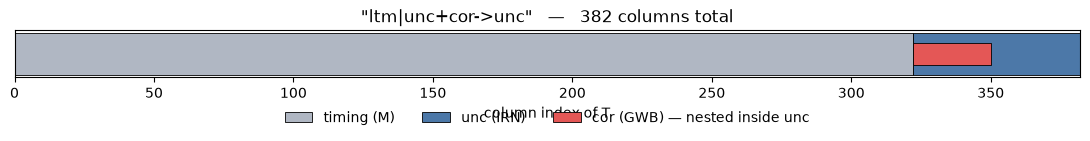

In [12]:
# Visualise the column layout of T.
fig, ax = plt.subplots(figsize=(11, 2.0))
n = rn.nmodes
bands = [("timing (M)",  0, rn.linear_timing_model_size, "#b0b7c3"),
         ("unc (IRN)",   rn.signal_comb_idxs["unc"].start, rn.signal_comb_idxs["unc"].stop, "#4c78a8"),
         ("cor (GWB)",   rn.signal_comb_idxs["cor"].start, rn.signal_comb_idxs["cor"].stop, "#e45756")]
for label, lo, hi, c in bands[:2]:
    ax.barh(0, hi - lo, left=lo, height=0.55, color=c, edgecolor="k", linewidth=.6, label=label)
lo, hi, c = bands[2][1], bands[2][2], bands[2][3]
ax.barh(0.0, hi - lo, left=lo, height=0.28, color=c, edgecolor="k", linewidth=.6,
        label=bands[2][0] + " — nested inside unc")
ax.set_yticks([]); ax.set_xlim(0, n); ax.set_xlabel("column index of T")
ax.set_title(f'"ltm|unc+cor->unc"   —   {n} columns total')
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.45), ncol=3, frameon=False)
plt.tight_layout(); plt.show()

---
# 5. The $\phi$ matrix and the red-noise parameter vector

`SuperSignal.model_maker()` (a method — *not* the NumPyro model function of the same name,
a genuinely confusing name collision in this codebase) builds a `parameterized` object
that turns a **flat parameter vector `xs`** into the prior covariance $\phi$ of the basis
coefficients and its inverse.

Because our model string contains `cor`, ATLAS selects `CorrelatedPulsarRedNoise`; without
it you would get `PerPulsarRedNoise`. The vector layout is

```
[ irn | dm | gtm | gwb_psd | orf ]
```

with the **pulsar index varying slowest** inside each block. `get_param_names()`
reproduces that ordering as strings — always use it to label your posterior samples rather
than assuming an order.

In [13]:
red_names = rn.model.get_param_names()
priors    = rn.model.get_param_names_and_priors()

print(f"{len(red_names)} red-noise parameters\n")
print(f"{'#':>3}  {'name':<28} {'prior':<20}")
for i, nm in enumerate(red_names):
    lo, hi = priors[nm]
    print(f"{i:>3}  {nm:<28} U({float(lo):>6.2f}, {float(hi):>6.2f})")

8 red-noise parameters

  #  name                         prior               
  0  B1855+09_irn_log10_A         U(-20.00, -11.00)
  1  B1855+09_irn_gamma           U(  0.00,   7.00)
  2  J1455-3330_irn_log10_A       U(-20.00, -11.00)
  3  J1455-3330_irn_gamma         U(  0.00,   7.00)
  4  J2317+1439_irn_log10_A       U(-20.00, -11.00)
  5  J2317+1439_irn_gamma         U(  0.00,   7.00)
  6  gwb_log10_A                  U(-18.00, -11.00)
  7  gwb_gamma                    U(  0.00,   7.00)


Eight red parameters: two per pulsar for the IRN power law, plus two for the GWB. Note
there are **no ORF parameters** — Hellings–Downs is fixed, so `orf_fixed` is true and the
ORF block is absent from the vector. If you swapped in `bin_orf` or `gt_orf` you would see
extra `orf_*` entries appended at the end, and *then* you would need
`lower_bound_orf`/`upper_bound_orf`.

Only the first 14 frequency bins get off-diagonal, ORF-weighted cross-pulsar structure in
$\phi$; bins 14–29 are diagonal and get a cheap reciprocal inverse rather than a Cholesky
(`parameterized.get_phi_mat_inv`). That split is the whole reason a nested `cor` slice is
worth the conceptual awkwardness.

---
# 6. `helpers` — where all the data goes

Now we compress. `rn.get_helpers` is a **jitted** function built at `SuperSignal`
construction time; which arguments it still expects depends on the run-mode flags we set
on `PTA_Data`. With `fixed_wn=None` and `fixed_res=False` (our case), the basis and the
$N$-matrix handler are already baked in, and it takes:

```python
helpers = rn.get_helpers(reff=<residuals>, white_noise_params=<flat wn vector>)
```

The residuals argument is the **concatenated** 1-D residual vector over all pulsars,
`jnp.concat(data.raw_residuals)`, matching the row-blocking of $T$.

In [14]:
raw_res = jnp.concat(data.raw_residuals)
print("concatenated residual vector:", raw_res.shape,
      f"(= {' + '.join(str(len(r)) for r in data.raw_residuals)})")

t0 = time.time()
helpers = rn.get_helpers(reff=raw_res, white_noise_params=wn_published)
TNT, TNr, rNr, logdet_N = helpers
print(f"built in {time.time() - t0:.2f} s (includes JIT compilation)\n")
print(f"  TNT       {str(TNT.shape):<20} = T^T N^-1 T,  per pulsar")
print(f"  TNr       {str(TNr.shape):<20} = T^T N^-1 r,  per pulsar")
print(f"  rNr       {'scalar':<20} = {float(rNr):.4f}")
print(f"  logdet_N  {'scalar':<20} = {float(logdet_N):.4f}")

concatenated residual vector: (32503,) (= 7758 + 10818 + 13927)
built in 4.31 s (includes JIT compilation)

  TNT       (3, 382, 382)        = T^T N^-1 T,  per pulsar
  TNr       (3, 382)             = T^T N^-1 r,  per pulsar
  rNr       scalar               = 33125.9193
  logdet_N  scalar               = -831706.0748


That is the entire dataset — 32,503 TOAs — reduced to a $[3, 382, 382]$ array, a
$[3, 382]$ array and two scalars. **Nothing downstream ever sees a TOA again.**

## The cost of varying white noise

Here is the single most important performance fact about a global fit. If white noise is
**fixed**, `helpers` is computed once, right here, outside the sampler, and passed in as a
constant. If white noise is **varied** — as in this notebook — then $N$ changes at every
leapfrog step, so `helpers` must be **rebuilt on every gradient evaluation**, including
the per-epoch Sherman–Morrison solves over all 32,503 TOAs. That is the dominant cost of
the whole analysis.

So `vary_white=True` is a scientific choice with a large, very concrete price. Time it
before you commit to a long run:

In [15]:
_ = rn.get_helpers(reff=raw_res, white_noise_params=wn_published)[0].block_until_ready()
t0 = time.time()
for _ in range(3):
    _ = rn.get_helpers(reff=raw_res, white_noise_params=wn_published)[0].block_until_ready()
per_call = (time.time() - t0) / 3
print(f"~{per_call*1e3:.0f} ms per helpers rebuild (post-compilation)")
print(f"-> a NUTS trajectory of 64 leapfrog steps costs ~{per_call*64:.1f} s in helper rebuilds alone")

~16 ms per helpers rebuild (post-compilation)
-> a NUTS trajectory of 64 leapfrog steps costs ~1.0 s in helper rebuilds alone


---
# 7. The standardizing transform

This is the heart of how ATLAS samples, and the thing most worth understanding before you
change anything.

## The problem

Our basis coefficients $a$ — the timing offsets $\epsilon$ *and* the Fourier amplitudes of
IRN and the GWB — are Gaussian with a prior covariance $\phi$ that is itself a function of
the parameters we are trying to infer ($\log_{10}A$, $\gamma$). That is a **hierarchical
funnel**: when the sampled amplitude is small, the coefficients are tightly constrained
near zero; when it is large, they range widely. The posterior is a narrow neck opening
into a wide mouth. HMC cannot choose a single step size that works in both regions — it
either rejects constantly in the neck or crawls in the mouth. This is exactly Neal's
funnel, and it is fatal at these dimensions.

## The fix: sample a standardized variable instead

Given the data-side precision $T^{\mathsf T}N^{-1}T$ and the prior precision $\phi^{-1}$,
the **conditional posterior of the coefficients is exactly Gaussian**:

$$
\Sigma^{-1} = T^{\mathsf T} N^{-1} T + \phi^{-1},
\qquad
\hat a = \Sigma\, T^{\mathsf T} N^{-1} r ,
\qquad
a \mid \theta \sim \mathcal N(\hat a, \Sigma).
$$

So rather than sampling $a$ directly, ATLAS samples a standard normal variable
$z \sim \mathcal N(0, I)$ and *deterministically maps* it through the conditional
posterior. Taking the Cholesky $\Sigma^{-1} = LL^{\mathsf T}$:

$$
\boxed{\;a = \hat a + L^{-\mathsf T} z\;}
$$

Check that this is right: $\operatorname{Cov}(a) = L^{-\mathsf T} L^{-1} =
(L L^{\mathsf T})^{-1} = \Sigma$. ✓

The change of variables contributes a Jacobian
$\left|\partial a / \partial z\right| = \left|L^{-\mathsf T}\right|$, hence

$$
\log\left|\det \frac{\partial a}{\partial z}\right| = -\sum_i \log L_{ii}.
$$

The point is that the *conditional* geometry in $z$ is now **exactly unit-normal at every
value of the spectral parameters**. The funnel between a spectrum and the coefficients it
governs has been absorbed into the deterministic map, so a single step size works
everywhere along the amplitude axis. (The joint posterior still has curvature coupling
$\theta$ and $z$ — this is not a free lunch, it is a *reparameterisation* — but the
pathological part of the geometry is gone.) This is why it is called a *standardizing*,
or non-centered, transform.

In `factorized/base.py` this is a handful of lines (`lnposterior_reparam`, ~line 1240):

```python
Sigma_inv   = TNT.at[:, diag, diag].add(phiinvs_diags.T)      # T^T N^-1 T + phi^-1
Sigma_inv_L = jsl.cho_factor(Sigma_inv, lower=True)           # L
a_hat       = jsl.cho_solve(Sigma_inv_L, TNr[..., None])      # MAP coefficients
Lz          = triangular_solve(Sigma_inv_L[0], z[..., None],  # L^-T z
                               left_side=True, lower=True, transpose_a=True)
coeff       = a_hat + Lz
lndet_Jac   = -jnp.sum(jnp.log(Sigma_inv_L[0].diagonal(axis1=-2, axis2=-1)))
```

## Where the linear timing model enters

For the timing columns, `phiinvs_diags` is set to `lowest_value_eq_to_zero = 1e-40` —
numerically a flat prior on $\epsilon$, but **present in the geometry** so that
$\Sigma^{-1}$ is well defined and NUTS has a finite gradient to follow. The padded dummy
columns instead get prior precision 1 and their own $-\tfrac12\sum(\text{pad} \cdot a)^2$
term. Both behaviours are switched on by `linear_timing and not marg_tm` — i.e. exactly
the mode we selected in §2.

Let us verify the identity numerically.

In [16]:
# Draw a red-noise parameter vector and evaluate the log posterior once.
x_test = jnp.array([-14.0, 3.2, -14.0, 3.2, -14.0, 3.2, -14.6, 13/3])
z_zero = jnp.zeros((data.npsrs, rn.nmodes))

lp, coeff = rn.lnposterior_reparam(helpers=helpers, red_params=x_test, z=z_zero)
print("log posterior at z = 0 :", float(lp))
print("coefficients          :", coeff.shape, " [npsr, nmodes]")
print("with z = 0 the coefficients are exactly the MAP vector a_hat")

log posterior at z = 0 : 391412.33113252744
coefficients          : (3, 382)  [npsr, nmodes]
with z = 0 the coefficients are exactly the MAP vector a_hat


In [17]:
# Verify Cov(a) = Sigma for one pulsar, directly from the transform.
import jax.scipy.linalg as jsl

phi_full = rn.model.get_phi_mat_full(x_test)
phiinvs, _ = rn.model.get_phi_mat_inv(phi_full)
phiinv_diag = phiinvs.diagonal(axis1=-2, axis2=-1)          # [nmodes_red, npsr]

# rebuild the timing-column padding exactly as lnposterior_reparam does
ltm = rn.linear_timing_model_size
pd = jnp.full((rn.nmodes, data.npsrs), rn.lowest_value_eq_to_zero)
pd = pd.at[ltm:, :].add(phiinv_diag)
pd = pd.at[:ltm, :].add(rn._pad_mask.T)

Sigma_inv = TNT.at[:, rn._diag_idx, rn._diag_idx].add(pd.T)
p = 0
L = jnp.linalg.cholesky(Sigma_inv[p])                        # lower
Linv_T = jnp.linalg.inv(L).T                                 # L^-T
cov_from_transform = Linv_T @ Linv_T.T                       # L^-T L^-1
Sigma_direct = jnp.linalg.inv(Sigma_inv[p])

err = float(jnp.max(jnp.abs(cov_from_transform - Sigma_direct)) /
            jnp.max(jnp.abs(Sigma_direct)))
print(f"max relative difference between L^-T L^-1 and Sigma : {err:.2e}")
print("log|det da/dz| = -sum(log diag L) =", float(-jnp.sum(jnp.log(jnp.diag(L)))))

max relative difference between L^-T L^-1 and Sigma : 2.61e-23
log|det da/dz| = -sum(log diag L) = -3199.7881265259684


## The cost: dimensionality

The price of making every coefficient explicit is that **all of them are sampled**. Here:

In [18]:
n_latent = data.npsrs * rn.nmodes
print(f"z_a latent dimensions : {data.npsrs} x {rn.nmodes} = {n_latent}")
print(f"red-noise parameters  : {len(red_names)}")
print(f"white-noise parameters: {len(wn_names)}")
print(f"TOTAL sampled dimension: {n_latent + len(red_names) + len(wn_names)}")

z_a latent dimensions : 3 x 382 = 1146
red-noise parameters  : 8
white-noise parameters: 39
TOTAL sampled dimension: 1193


1,146 latent coefficients for three pulsars. For the full 67-pulsar NANOGrav array with an
Adaptus basis this becomes **~37,600** — which is why ATLAS also offers
`partial_marg_lnposterior`, a third likelihood that analytically marginalises the
per-pulsar block (timing + IRN + Adaptus) via a Schur complement and keeps only the GWB
coefficients explicit, dropping ~37,600 latent dimensions to ~1,876. You select it with
`marg_over_non_gwb=True`.

**We do not use it here**, for two reasons. First, at three pulsars the full
parameterisation is perfectly tractable. Second — and this would bite you —
`partial_marg_lnposterior_helper` unconditionally indexes
`signal_comb_idxs['timing']`, `['unc']` **and** `['gtm']`, so a model string without a
`gtm` component (like ours) raises `KeyError: 'gtm'` rather than marginalising over
whichever non-GWB blocks actually exist. If you want partial marginalisation, you
currently need an Adaptus basis in the model too.

---
# 8. The NumPyro model

`ATLAS.samplers.canetoadracing.model_maker` is the actual NumPyro model of the whole PTA.
(It is somewhat buried: it lives at the bottom of a file whose first 675 lines are a
vendored copy of Coleman Krawczyk's `MultiHMCGibbs` sampler.) Let us just read it.

In [19]:
print(inspect.getsource(model_maker))

def model_maker(raw_residuals, 
                super_sig,
                marg_over_non_gwb,
                vary_white = False,
                wn_lower_bound = None,
                wn_upper_bound = None,
                tm_model = None,
                helpers = None,
                save_red_coeff = False,
                fixed_white_noise_params = None,
                ):
                
    ######################################## Timing Model ########################################
    if tm_model:
        lam = numpyro.sample("timing_lam", dist.HalfNormal(10.0))
        k = numpyro.sample("timing_k", dist.Normal(0, 50).expand([tm_model.nparams_total]))
        stochastic_res = tm_model.residuals(k * lam)
    else:
        stochastic_res = raw_residuals

    ######################################## White Noise ########################################
    if vary_white:
        theta_wn = numpyro.sample('white_noise', dist.Uniform(wn_lower_bound, wn_upper_bound))
        helpe

Walking through it for **our** configuration:

1. **Timing model.** `tm_model=None`, so `stochastic_res = raw_residuals`. (The `tm_model`
   branch is philosophy (c), the nonlinear JUG path — not ours.)

2. **White noise.** `vary_white=True`, so
   ```python
   theta_wn = numpyro.sample('white_noise', dist.Uniform(wn_lower_bound, wn_upper_bound))
   helpers_now = super_sig.get_helpers(reff=stochastic_res, white_noise_params=theta_wn)
   ```
   The `helpers` we built in §6 are **ignored** — they are rebuilt from the sampled
   white-noise vector every single gradient evaluation. Note also that this path puts a
   **uniform** prior on EFAC, taken from the bounds we set. `SinglePulsarWhiteCov` also
   offers `make_numpyro_prior()`, which gives each backend a *named* site and a truncated-
   normal EFAC prior centred on 1 — a common alternative literature choice — but
   `model_maker` does not use it. If you want that prior, write your own model function.

3. **Red noise.**
   ```python
   xs = numpyro.sample('red_noise', dist.Uniform(model.lower_prior_lim_all,
                                                 model.upper_prior_lim_all))
   ```
   i.e. exactly the uniform prior ranges we tabulated in §5, in the `get_param_names()`
   order.

4. **Coefficients and the likelihood.** With `marg_over_non_gwb=False`:
   ```python
   z_a = numpyro.sample('z_a', dist.Normal(0, 1).expand((npsrs, nmodes)))
   lprob, coeff = super_sig.lnposterior_reparam(helpers=helpers_now, red_params=xs, z=z_a)
   ```

5. **The correction term you must not delete.**
   ```python
   numpyro.factor('lnpost', lprob + 0.5 * jnp.sum(z_a**2))
   ```
   `lprob` returned by `lnposterior_reparam` is the *complete* log posterior in
   coefficient space — it already contains the exact Gaussian prior on $a$ **and** the
   Jacobian $-\sum_i \log L_{ii}$. But NumPyro has separately already added
   $\log \mathcal N(z; 0, I) = -\tfrac12\sum z^2 + \text{const}$ for the `z_a` site.
   Adding $+\tfrac12\sum z^2$ back cancels that double-count exactly, leaving `lprob`
   (up to an irrelevant constant). **Remove this term and your posterior is silently
   wrong** — it will still run, still look plausible, and give you the wrong answer.

---
# 9. Initialisation

NUTS initialised from a random draw of these priors will start with EFACs anywhere in
$(0.01, 10)$ and red-noise amplitudes anywhere over nine decades — a place where the
likelihood is astronomically bad and warmup may never recover.

Initialise deliberately with `init_to_value`:

* **white noise** at the published NG15 values,
* **red noise** at plausible values ($\log_{10}A \approx -14$, $\gamma \approx 3.2$ for
  IRN; the 15 yr GWB result $\log_{10}A \approx -14.6$, $\gamma = 13/3$),
* **`z_a` at zero**, which by the transform above starts every coefficient exactly at its
  MAP value $\hat a$ — the best possible starting point.

In [20]:
rn_init = []
for _ in data.psr_names:
    rn_init += [-14.0, 3.2]        # per-pulsar IRN: log10_A, gamma
rn_init += [-14.6, 13/3]           # GWB: log10_A, gamma
rn_init = jnp.array(rn_init)
assert len(rn_init) == len(red_names)

init_values = {
    "white_noise": wn_published,
    "red_noise":   rn_init,
    "z_a":         jnp.zeros((data.npsrs, rn.nmodes)),
}
for k, v in init_values.items():
    print(f"{k:<12} {v.shape}")

white_noise  (39,)
red_noise    (8,)
z_a          (3, 382)


---
# 10. Running NUTS

A few notes on the settings:

* `target_accept_prob=0.8` is the NumPyro default and is usually fine here; raise it to
  0.9 if you see divergences.
* `max_tree_depth` caps the trajectory at $2^{d}$ leapfrog steps. **With
  `vary_white=True` each of those steps rebuilds `helpers`**, so this parameter directly
  multiplies your wall-clock cost. Do the arithmetic before you launch: at the
  ~320 ms/rebuild measured in §6 on CPU, `max_tree_depth=7` means up to
  $2^7 = 128$ steps $\approx$ **40 s per iteration**. We use 5 here (up to 31 steps,
  ~10 s/iteration); check the reported `num_steps` afterwards and raise it if trajectories
  are hitting the cap.
* NumPyro stores every sample site, and `z_a` is $[3, 382]$ per sample — for 3,000 samples
  that is ~3.4M floats. Expect the output to be dominated by coefficients, not parameters.

The settings below are deliberately small so the notebook completes in roughly
**20–30 minutes on CPU** (much less on a GPU — this code is written to be batched over
pulsars for exactly that reason). They are a pipeline demonstration, **not** a converged
run. For a real analysis use `num_warmup=500, num_samples=3000`, run several chains, and
budget hours.

In [21]:
NUM_WARMUP  = 50      # <-- raise to ~500 for a real run
NUM_SAMPLES = 100     # <-- raise to ~3000 for a real run

nuts_kernel = NUTS(
    model              = model_maker,
    target_accept_prob = 0.8,
    max_tree_depth     = 5,     # <-- see the cost note above before raising this
    init_strategy      = init_to_value(values=init_values),
)

mcmc = MCMC(nuts_kernel, num_warmup=NUM_WARMUP, num_samples=NUM_SAMPLES, num_chains=1)

t0 = time.time()
mcmc.run(
    jrandom.key(170817),
    raw_residuals    = raw_res,
    super_sig        = rn,
    vary_white       = True,            # <-- rebuild helpers every leapfrog step
    wn_lower_bound   = wn_lower_bound,
    wn_upper_bound   = wn_upper_bound,
    tm_model         = None,            # not using the nonlinear JUG timing model
    helpers          = None,            # ignored when vary_white=True
    save_red_coeff   = False,           # set True to also store the coefficient vector
    marg_over_non_gwb = False,          # full lnposterior_reparam
    extra_fields     = ("diverging", "num_steps"),
)
print(f"\nfinished in {(time.time() - t0)/60:.1f} min")

sample: 100%|██████████| 150/150 [02:57<00:00,  1.19s/it, 31 steps of size 1.17e-01. acc. prob=0.97]


finished in 3.4 min


In [22]:
samples = mcmc.get_samples()
extra   = mcmc.get_extra_fields()

for k, v in samples.items():
    print(f"{k:<12} {v.shape}")
print()
print("divergences        :", int(np.asarray(extra['diverging']).sum()), "/", NUM_SAMPLES)
print("mean leapfrog steps:", float(np.asarray(extra['num_steps']).mean()))

red_noise    (100, 8)
white_noise  (100, 39)
z_a          (100, 3, 382)

divergences        : 0 / 100
mean leapfrog steps: 31.0


---
# 11. Looking at the results

The `red_noise` samples are a bare `[nsamples, 8]` array — **use
`rn.model.get_param_names()` to label the columns**, never a hand-written ordering.
Likewise `wn.get_param_names()` for the white noise.

In [23]:
red_chain = np.asarray(samples["red_noise"])
wn_chain  = np.asarray(samples["white_noise"])

red_df = {nm: red_chain[:, i] for i, nm in enumerate(red_names)}
wn_df  = {nm: wn_chain[:, i]  for i, nm in enumerate(wn_names)}

print(f"{'parameter':<28} {'mean':>8} {'std':>8} {'16%':>8} {'84%':>8}")
for nm, v in red_df.items():
    q16, q84 = np.percentile(v, [16, 84])
    print(f"{nm:<28} {v.mean():>8.3f} {v.std():>8.3f} {q16:>8.3f} {q84:>8.3f}")

parameter                        mean      std      16%      84%
B1855+09_irn_log10_A          -14.102    0.435  -14.606  -13.687
B1855+09_irn_gamma              4.128    1.112    3.121    5.239
J1455-3330_irn_log10_A        -16.220    1.811  -18.302  -14.346
J1455-3330_irn_gamma            3.467    2.255    0.819    6.526
J2317+1439_irn_log10_A        -16.916    1.917  -19.353  -15.098
J2317+1439_irn_gamma            2.634    1.674    0.455    4.450
gwb_log10_A                   -15.244    1.127  -16.286  -14.097
gwb_gamma                       3.548    1.519    1.742    5.057


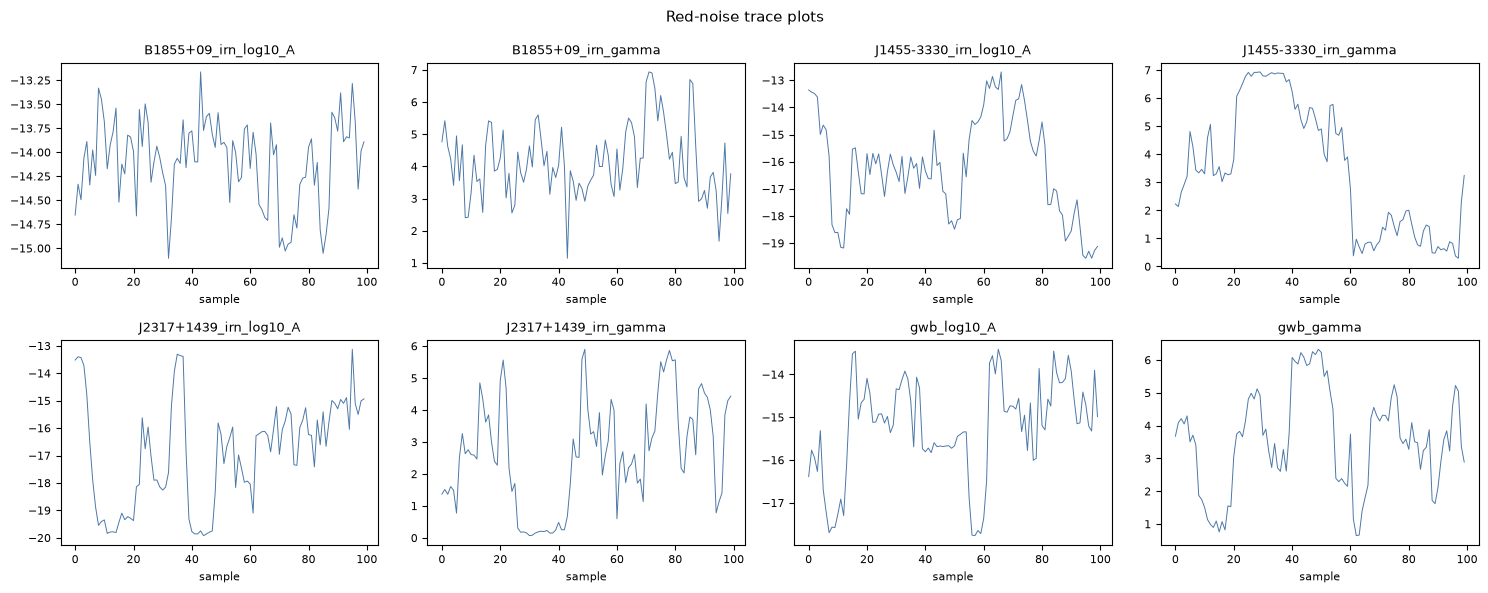

In [24]:
fig, axes = plt.subplots(2, 4, figsize=(15, 6))
for ax, nm in zip(axes.ravel(), red_names):
    v = red_df[nm]
    ax.plot(v, lw=.7, color="#4c78a8")
    ax.set_title(nm, fontsize=9)
    ax.set_xlabel("sample", fontsize=8)
    ax.tick_params(labelsize=8)
fig.suptitle("Red-noise trace plots", fontsize=11)
plt.tight_layout(); plt.show()

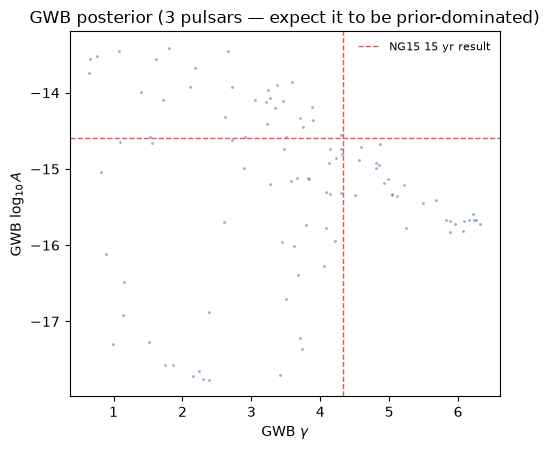

In [25]:
# The GWB 2-D posterior -- the plot everyone actually wants.
fig, ax = plt.subplots(figsize=(5.2, 4.6))
ax.plot(red_df["gwb_gamma"], red_df["gwb_log10_A"], ".", ms=2.5, alpha=.4, color="#4c78a8")
ax.axhline(-14.6, ls="--", lw=1, color="#e45756", label="NG15 15 yr result")
ax.axvline(13/3,  ls="--", lw=1, color="#e45756")
ax.set_xlabel(r"GWB $\gamma$"); ax.set_ylabel(r"GWB $\log_{10}A$")
ax.set_title("GWB posterior (3 pulsars — expect it to be prior-dominated)")
ax.legend(fontsize=8, frameon=False)
plt.tight_layout(); plt.show()

With only three pulsars and 3 pulsar pairs there is essentially **no** Hellings–Downs
information — a 3-pulsar array cannot distinguish a correlated background from three
independent red-noise processes, and the GWB posterior here should be treated as a
pipeline test, not a measurement. That is the point of this notebook: it demonstrates the
machinery end to end at a size where every array is small enough to inspect.

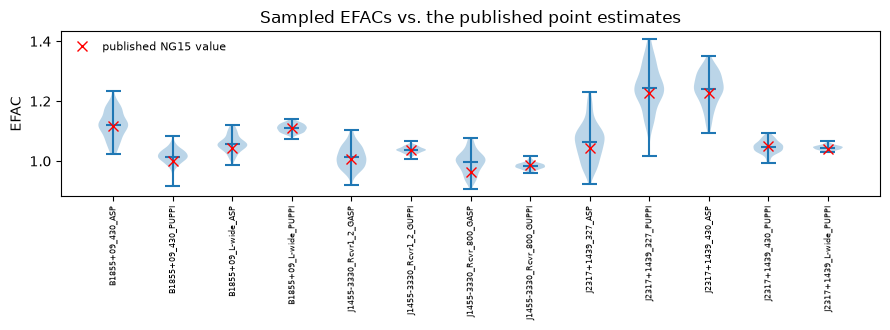

In [26]:
# White noise: did it actually move away from the published values?
fig, ax = plt.subplots(figsize=(9, 3.4))
efac_idx = [i for i, nm in enumerate(wn_names) if nm.endswith("_efac")]
ax.violinplot([wn_chain[:, i] for i in efac_idx], showmeans=True)
ax.plot(range(1, len(efac_idx) + 1), np.asarray(wn_published)[efac_idx],
        "rx", ms=7, label="published NG15 value")
ax.set_xticks(range(1, len(efac_idx) + 1))
ax.set_xticklabels([wn_names[i].replace("_efac", "") for i in efac_idx],
                   rotation=90, fontsize=6)
ax.set_ylabel("EFAC"); ax.legend(fontsize=8, frameon=False)
ax.set_title("Sampled EFACs vs. the published point estimates")
plt.tight_layout(); plt.show()

This plot is the whole argument for a global fit in one picture: those EFAC posteriors
have **width**, and that width is propagating into the GWB posterior. In a staged
analysis, every one of those parameters would have been frozen at the red cross.

z_a: (100, 3, 382)


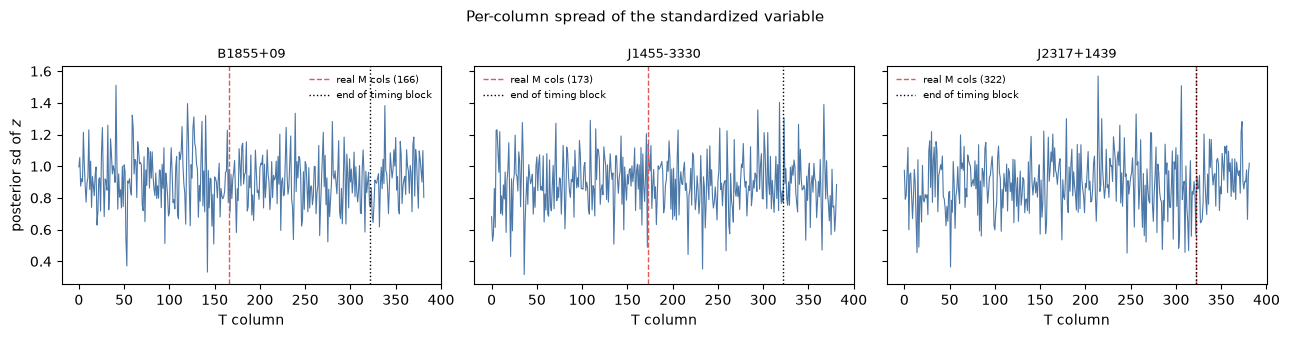

In [27]:
# The sampled linear timing-model coefficients live in z_a's timing columns.
z_chain = np.asarray(samples["z_a"])           # [nsamples, npsr, nmodes]
print("z_a:", z_chain.shape)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.4), sharey=True)
for ax, (pidx, name) in zip(axes, enumerate(data.psr_names)):
    n_real = int(data.Mmat[pidx].shape[1])
    sd = z_chain[:, pidx, :].std(axis=0)
    ax.plot(sd, lw=.8, color="#4c78a8")
    ax.axvline(n_real, color="#e45756", ls="--", lw=1,
               label=f"real M cols ({n_real})")
    ax.axvline(rn.linear_timing_model_size, color="k", ls=":", lw=1,
               label="end of timing block")
    ax.set_title(name, fontsize=9); ax.set_xlabel("T column"); ax.legend(fontsize=7, frameon=False)
axes[0].set_ylabel("posterior sd of $z$")
fig.suptitle("Per-column spread of the standardized variable", fontsize=11)
plt.tight_layout(); plt.show()

Between the red dashed line and the black dotted line are the **padded dummy columns**.
Their $z$ has unit spread by construction (that is the `_pad_mask` unit-variance Gaussian
doing its job) and they carry no information — a useful visual check that the padding
scheme is behaving.

---
# 12. What to change, and what to watch out for

## Where to look, given what you want to change

| Goal | Where |
|---|---|
| New spectral shape | `psd_functions.py` — write `f(f, df, *params)`, pass as `irn_psd_function` / `gwb_psd_function` |
| New ORF | `psd_functions.py` (**not** `signals/orf_functions.py`, which is vestigial) — signature `f(angle, *params)` |
| Fix a spectral parameter | wrap in `functools.partial`, e.g. `partial(powerlaw, gamma=13/3)` |
| Change the white-noise model | `nMatrix/base.py` — `get_nvec_jvec`, `_solve_unmarg` |
| Change the likelihood/transform | `factorized/base.py:1202–1413` — and **check the matching `numpyro.factor` correction** |
| Gibbs blocking instead of one big NUTS | `canetoadracing.py` — `MultiHMCGibbs.gibbs_sites_list` |
| Label posterior samples | `rn.model.get_param_names()`, `wn.get_param_names()` |

## Traps in the current codebase

* **Construction order.** White noise **must** be built before red noise (§3). Unenforced.
* **`dm` is broken.** Any model string containing `dm` raises `AttributeError`:
  `PTA_Data` stores the argument as `self.dm_bins` but `make_red_noise` reads
  `self.data.num_dm_bins`. DM noise is unreachable through the public API until that
  attribute is renamed.
* **Partial marginalisation needs `gtm`.** `marg_over_non_gwb=True` requires the model
  string to contain a timing prefix, `unc` **and** `gtm`; otherwise `KeyError`.
* **ORF bounds in the reference script are inverted.** See the warning in §4.
* **`ln_likelihood_curn` has no caller** anywhere in the repo. It is a correct reference
  implementation of the Enterprise-style marginal likelihood (coefficients integrated out,
  $\phi$ strictly diagonal, no cross-pulsar correlation) and is genuinely useful for
  validating a CURN run against a known-good result — but you have to wire it yourself.
* **`SuperSignal.model_maker` vs `canetoadracing.model_maker`** are unrelated things with
  the same name. Grep for one and you find the other.

## Scaling this up

Going from 3 pulsars to 67 changes which choices are affordable:

1. **Turn on `marg_over_non_gwb=True`** (and add a `gtm` block so it works) — this is the
   single biggest win, dropping the latent dimension by ~20×.
2. **Reconsider `vary_white=True`.** Rebuilding `helpers` every leapfrog step over ~500k
   TOAs is brutal. The intended alternative is to put white noise in its own Gibbs block
   (`MultiHMCGibbs`) so its expensive rebuild is amortised, rather than paying it on every
   gradient of every parameter.
3. **Do not split the GWB spectrum from the IRN spectra into different Gibbs blocks.**
   They are severely degenerate — a common process is absorbable into $N_\mathrm{psr}$
   individual ones, and in our model string the GWB literally occupies the same columns as
   the IRN. Gibbs on strongly correlated Gaussians pays a $1/(1-\rho^2)$ mixing penalty
   with $\rho$ routinely above 0.9.